In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA

In [ ]:
speech_df = pd.read_csv('lemma.csv')
speech_df_raw = pd.read_csv('file2.csv')

In [ ]:
speech_df.head()

,Unnamed: 0.1,Unnamed: 0,speaker,year,transcript,length
0,0,0,OPRAH WINFREY,1918.0,thank wallis annenberg special thank dean will...,15301.0
1,1,1,OPRAH WINFREY,2007.0,president swygert trustees distinguish guests ...,14168.0
2,2,2,FRANKLIN D ROOSEVELT,1932.0,day honorable attainment honor confer upon dee...,16017.0
3,3,3,WILLIAM ALLEN,1936.0,commencement orator auditors turn face around ...,14953.0
4,4,4,CARRIE CHAPMAN,1936.0,bring message sweet briar college especially s...,22942.0


VADER

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# Instantiate the analyzer
analyzer = SIA()

In [ ]:
# Test sentence
print(analyzer.polarity_scores('The phone is super cool'))

# Test sentence with punctuation
print(analyzer.polarity_scores('The phone is super cool!!!'))

{'neg': 0.0, 'neu': 0.326, 'pos': 0.674, 'compound': 0.7351}
{'neg': 0.0, 'neu': 0.298, 'pos': 0.702, 'compound': 0.795}


##Overall Polarity

In [ ]:
results = []
for i in range(len(speech_df)):
    test = speech_df.transcript.iloc[i]
    ana = analyzer.polarity_scores(test)
    results.append([ana['neg'],ana['neu'],ana['pos'],ana['compound']])

In [ ]:
vader_df = pd.DataFrame(results,columns=['neg','neu','pos','compound'])
vader_df

,neg,neu,pos,compound
0,0.122,0.628,0.250,0.9996
1,0.065,0.658,0.276,0.9998
2,0.113,0.643,0.244,0.9995
3,0.109,0.643,0.248,0.9997
4,0.081,0.770,0.149,0.9993
...,...,...,...,...
317,0.089,0.582,0.328,0.9999
318,0.068,0.703,0.229,0.9996
319,0.136,0.623,0.242,0.9993
320,0.105,0.673,0.222,0.9995


##Analysing Sentiment based on parts

In [ ]:
# Split each speech into 10 parts

def split_text(text, n=10):
    '''Takes in a string of text and splits into n equal parts, with a default of 10 equal parts.'''

    # Calculate length of text, the size of each chunk of text and the starting points of each chunk of text
    length = len(text)
    size = math.floor(length / n)
    start = np.arange(0, length, size)

    # Pull out equally sized pieces of text and put it into a list
    split_list = []
    for piece in range(n):
        split_list.append(text[start[piece]:start[piece]+size])
    return split_list

In [ ]:
def simple_plot(y,df,xlabel,ylabel,title):
    plt.plot(df.index,df[y])
    plt.title(title,fontsize=16)
    plt.ylabel(xlabel,fontsize=16)
    plt.xlabel(ylabel,fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12);

In [ ]:
def polarity_speech(transcript):
    """
    Input: one transcript (with original punctuation)
    Output: polarity plot throughout the speech

    Divide the transript to 10 sections

    """
#     sents = transcript.split(".")

    sents = split_text(transcript, n=10)

    results = []
    for sent in sents:
        ana = analyzer.polarity_scores(sent)
        results.append([ana['neg'],ana['neu'],ana['pos'],ana['compound']])

    vader_sent_df = pd.DataFrame(results,columns=['neg','neu','pos','compound'])

    return simple_plot('compound',vader_sent_df,\
                'Polarity','',\
                title = '')

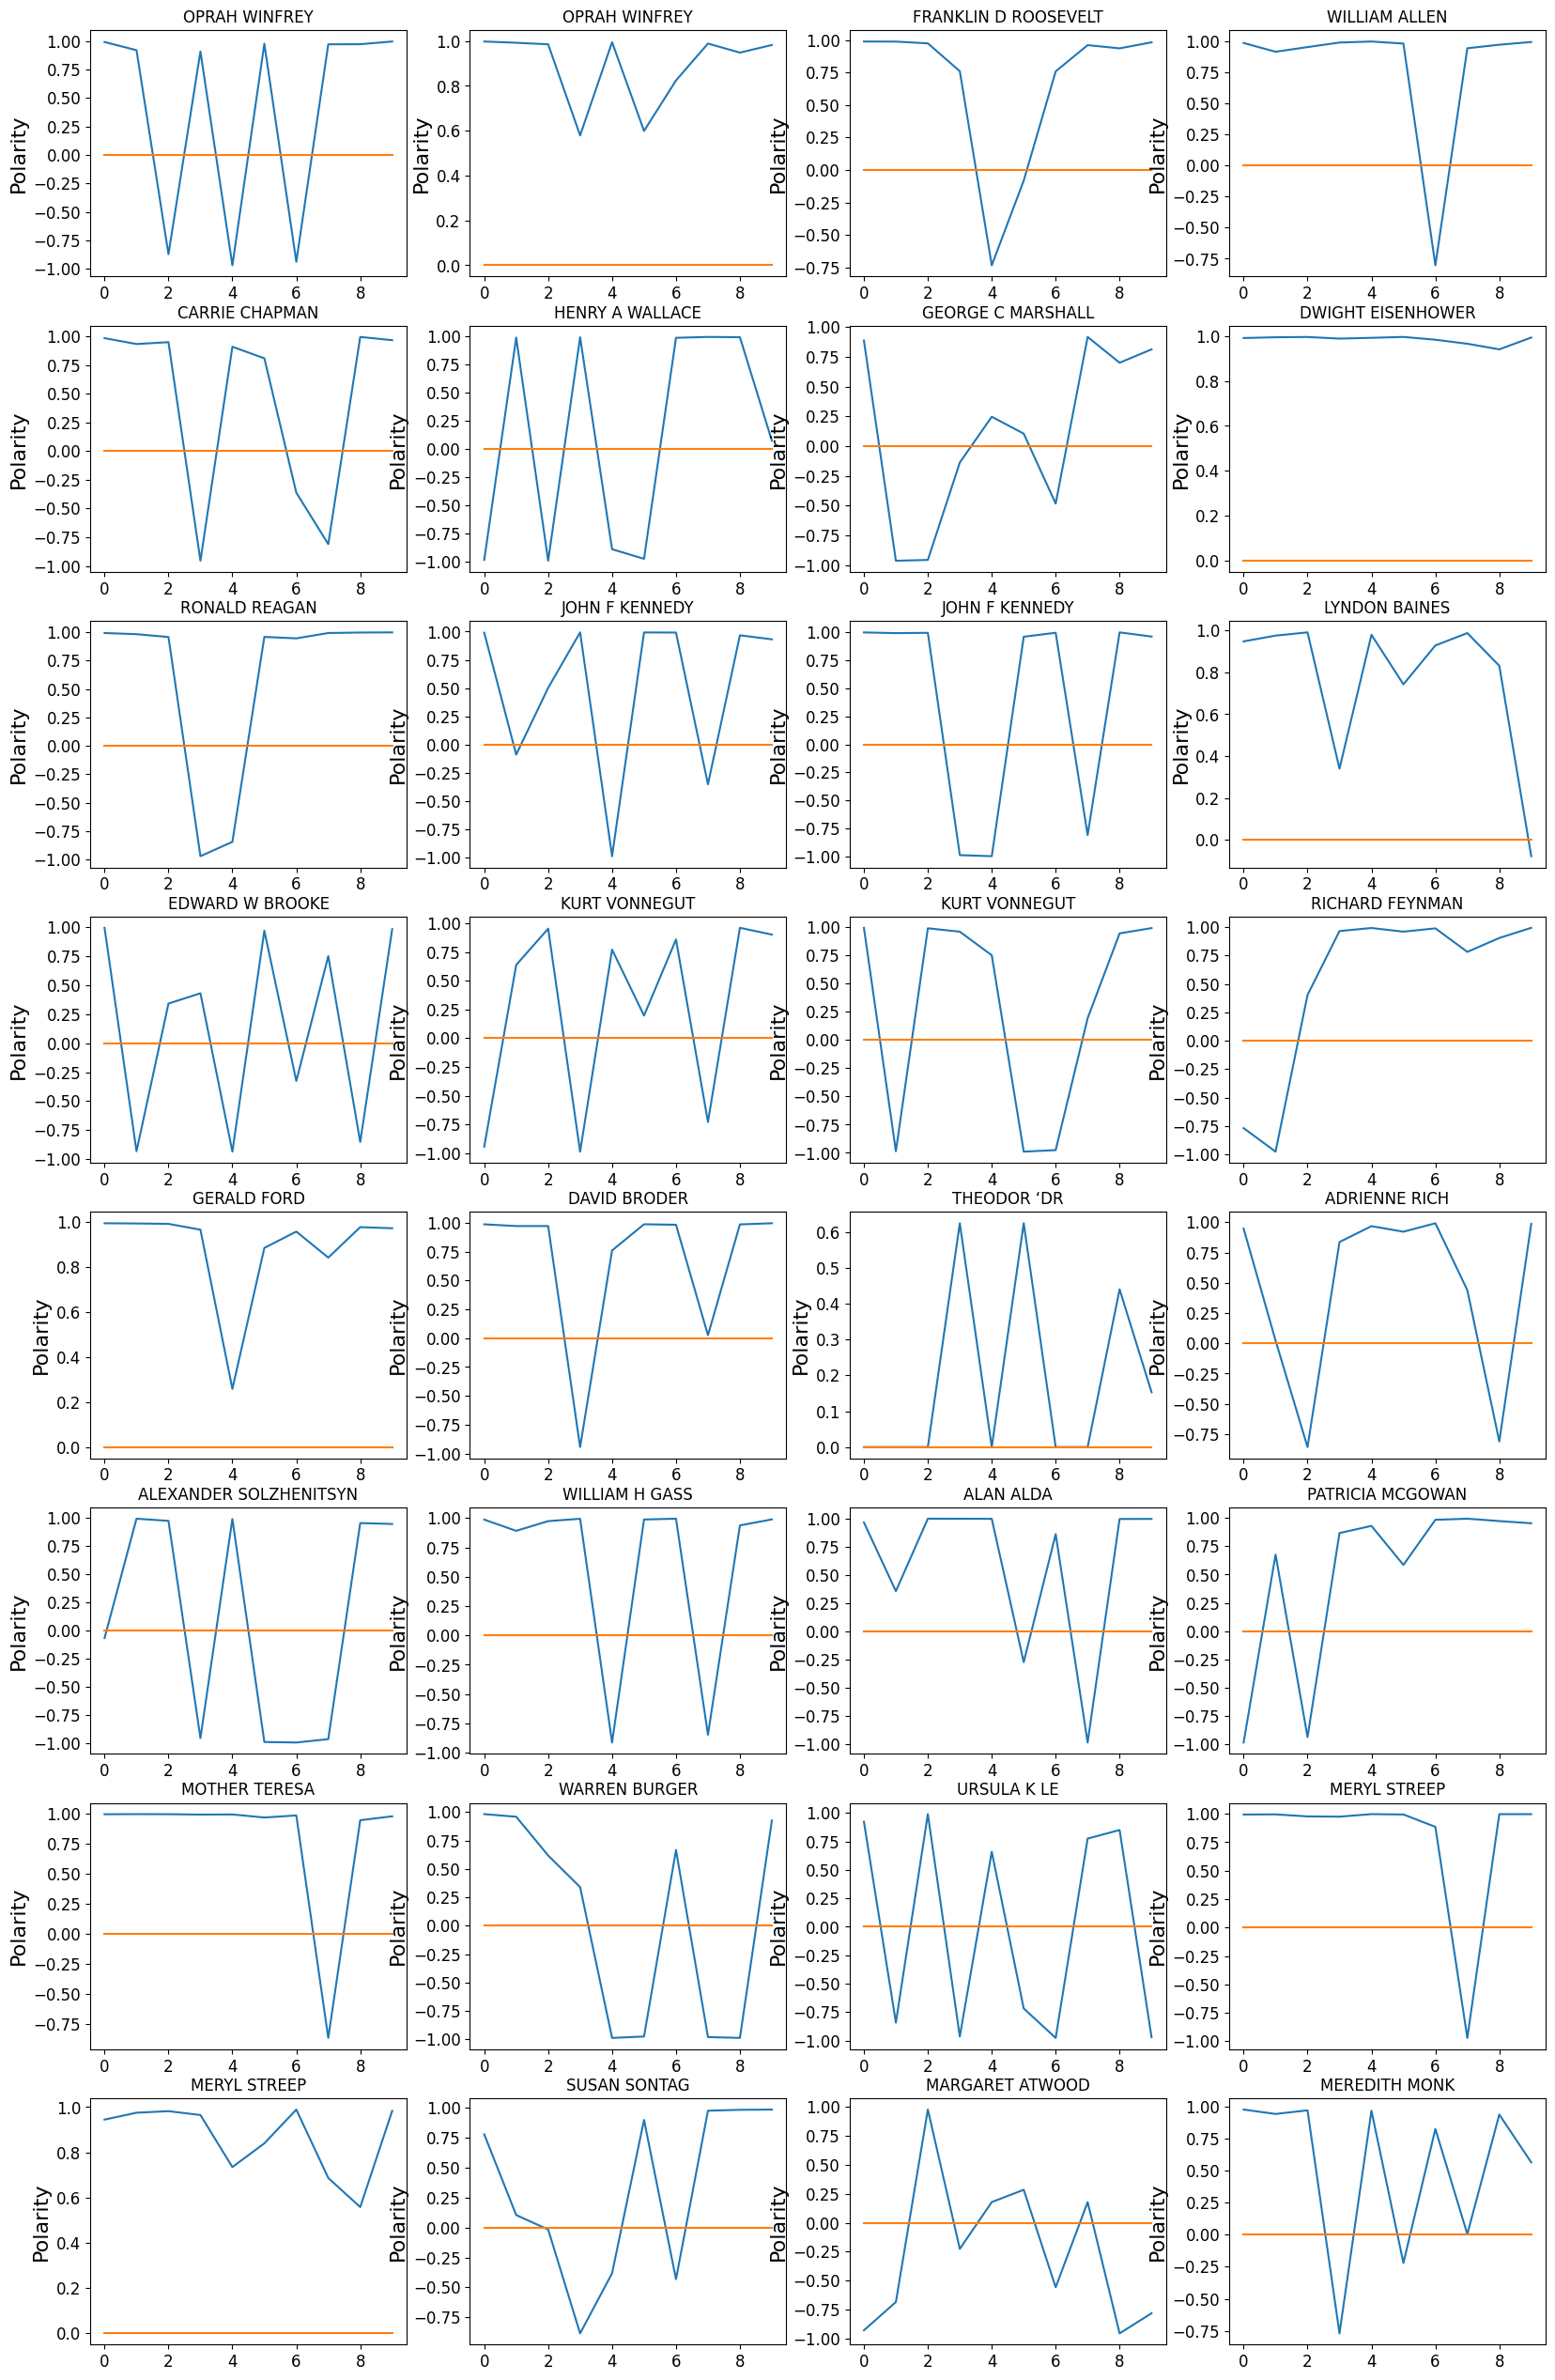

In [ ]:
# Check the first 30 speeches

plt.rcParams['figure.figsize'] = [20, 32]

num_speech = 32
for i in range(num_speech):
    test = speech_df_raw.transcript.iloc[i]
    plt.subplot(num_speech//4,4,i+1)
    polarity_speech(test)
    plt.plot(np.arange(0,10), np.zeros(10))
    plt.title(speech_df_raw.speaker.iloc[i])


plt.show()


##Taking Average of All transcripts

In [ ]:
# Split and analyze all transcripts

all_transcripts = []

for i in range(speech_df_raw.shape[0]):
    transcript = speech_df_raw.transcript.iloc[i]
    sents = split_text(transcript, n=10)
    results = []
    for sent in sents:
        ana = analyzer.polarity_scores(sent)
    #     results.append([ana['neg'],ana['neu'],ana['pos'],ana['compound']])
        results.append(ana['compound'])
    all_transcripts.append(results)

In [ ]:
# Create df
vader_sent_df = pd.DataFrame(all_transcripts,
                             columns=[str(i+1) for i in range(10)]
                            )
vader_sent_df['Transcript'] = [i for i in range(322)]

In [ ]:
vader_sent_df

,1,2,3,4,5,6,7,8,9,10,Transcript
0,0.9912,0.9195,-0.8707,0.9082,-0.9683,0.9761,-0.9375,0.9711,0.9720,0.9957,0
1,0.9980,0.9924,0.9855,0.5794,0.9949,0.5994,0.8243,0.9889,0.9485,0.9825,1
2,0.9891,0.9884,0.9750,0.7604,-0.7338,-0.0817,0.7590,0.9612,0.9364,0.9827,2
3,0.9860,0.9153,0.9531,0.9895,0.9978,0.9812,-0.8030,0.9436,0.9720,0.9939,3
4,0.9851,0.9338,0.9502,-0.9552,0.9103,0.8095,-0.3619,-0.8100,0.9957,0.9675,4
...,...,...,...,...,...,...,...,...,...,...,...
317,0.9735,0.9454,0.9940,0.7832,-0.8604,0.9962,0.9382,0.9963,0.9980,0.9989,317
318,0.9783,0.9920,0.9769,-0.9590,0.9814,0.9621,0.8118,0.8037,0.4924,0.9702,318
319,0.9904,-0.9878,0.2670,0.7168,0.9552,0.9750,-0.9233,0.9908,-0.7809,0.9957,319
320,0.9678,0.9403,0.9611,0.9575,0.9884,0.9762,0.7139,0.9457,-0.9149,0.9634,320


<ipython-input-29-eb014a1b6065>:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=vader_sent_melt, x="variable", y="value", palette='Spectral')


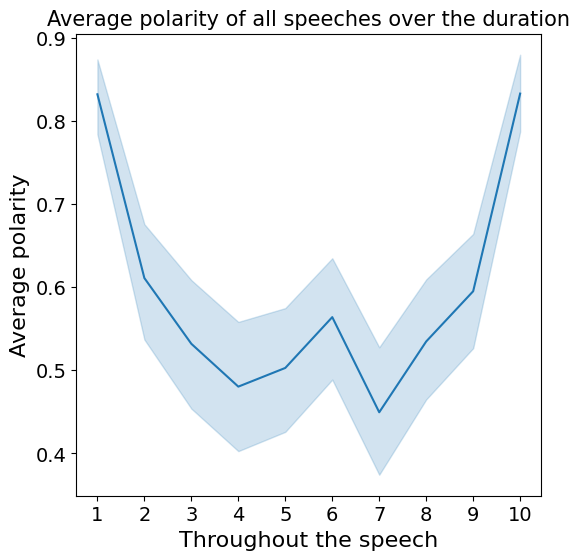

In [ ]:
# Melt df (for sns lineplot 95% confidence interval)
vader_sent_melt = pd.melt(vader_sent_df, id_vars='Transcript', value_vars = [str(i+1) for i in range(10)],
#                          val_name = [str(i+1) for i in range(10)]
                         )

# sns lineplot
fig,ax = plt.subplots(figsize=[6,6])
sns.lineplot(data=vader_sent_melt, x="variable", y="value", palette='Spectral')
ax.set_title('Average polarity of all speeches over the duration',fontsize=15)
ax.set_ylabel('Average polarity',fontsize=16)
ax.set_xlabel('Throughout the speech',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14);

#Overall Analysis

In [ ]:
# Create quick lambda functions to find the polarity and subjectivity of each routine
# Terminal / Anaconda Navigator: conda install -c conda-forge textblob
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

speech_df_raw['polarity'] = speech_df_raw['transcript'].apply(pol)
speech_df_raw['subjectivity'] = speech_df_raw['transcript'].apply(sub)
speech_df_raw

,Unnamed: 0,speaker,year,transcript,length,polarity,subjectivity
0,0,OPRAH WINFREY,1918.0,thank you wallis annenberg and a special thank...,15301.0,0.125145,0.495675
1,1,OPRAH WINFREY,2007.0,president swygert trustees distinguished guest...,14168.0,0.175982,0.512606
2,2,FRANKLIN D ROOSEVELT,1932.0,for me as for you this is a day of honorable a...,16017.0,0.120859,0.459659
3,3,WILLIAM ALLEN,1936.0,about all that a commencement orator can do fo...,14953.0,0.182434,0.485899
4,4,CARRIE CHAPMAN,1936.0,i bring a message to sweet briar college and e...,22942.0,0.113408,0.434663
...,...,...,...,...,...,...,...
317,317,ROBERT IGER,2021.0,good evening president hartzell chairman eltif...,13240.0,0.231863,0.556235
318,318,KEN JEONG,2022.0,thank you president fitts provost forman disti...,10994.0,0.135613,0.466744
319,319,JOHN ROTH,2022.0,as you have heard i am a historian after year...,13648.0,0.187867,0.507297
320,320,TAYLOR SWIFT,2022.0,last time i was in a stadium this size i was d...,14908.0,0.144014,0.523619


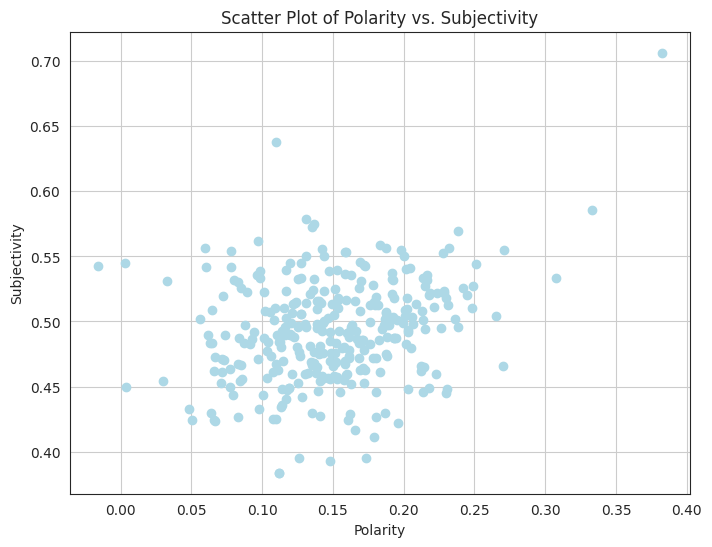

In [ ]:
# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(speech_speaker_region['polarity'], speech_speaker_region['subjectivity'], color='lightblue')

# Add labels and title
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.title('Scatter Plot of Polarity vs. Subjectivity')

# Show plot
plt.grid(True)
plt.show()

##School Info based Analysis

In [ ]:
speech_speaker_region = pd.read_csv('final.csv')
speech_speaker_region['region'] = speech_speaker_region['longitude'].apply(lambda x: 'West' if x < -109 else(\
                                                                            'Central' if -109 < x < -88\
                                                                            else 'East'))
speech_speaker_region.head()

,speaker,profession,category,year,school,transcript,length,latitude,longitude,region
0,OPRAH WINFREY,host and television producer,Entertainment,1918,USC,thank you wallis annenberg and a special thank...,15301,34.022415,-118.285530,West
1,OPRAH WINFREY,host and television producer,Entertainment,2007,HOWARD UNIVERSITY,president swygert trustees distinguished guest...,14168,38.922684,-77.019438,East
2,FRANKLIN D ROOSEVELT,Politician,Politics,1932,OGLETHORPE UNIVERSITY,for me as for you this is a day of honorable a...,16017,33.912594,-84.325560,East
3,WILLIAM ALLEN,"Author, Political Scientist",Publish,1936,WHITE NORTHWESTERN UNIVERSITY,about all that a commencement orator can do fo...,14953,42.055984,-87.675171,East
4,CARRIE CHAPMAN,Women's suffrage leader,Politics,1936,CATT SWEET BRIAR COLLEGE,i bring a message to sweet briar college and e...,22942,37.557809,-79.082886,East


In [ ]:
pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

speech_speaker_region['polarity'] = speech_speaker_region['transcript'].apply(pol)
speech_speaker_region['subjectivity'] = speech_speaker_region['transcript'].apply(sub)

speech_speaker_region.head()

,speaker,profession,category,year,school,transcript,length,latitude,longitude,region,polarity,subjectivity
0,OPRAH WINFREY,host and television producer,Entertainment,1918,USC,thank you wallis annenberg and a special thank...,15301,34.022415,-118.285530,West,0.125145,0.495675
1,OPRAH WINFREY,host and television producer,Entertainment,2007,HOWARD UNIVERSITY,president swygert trustees distinguished guest...,14168,38.922684,-77.019438,East,0.175982,0.512606
2,FRANKLIN D ROOSEVELT,Politician,Politics,1932,OGLETHORPE UNIVERSITY,for me as for you this is a day of honorable a...,16017,33.912594,-84.325560,East,0.120859,0.459659
3,WILLIAM ALLEN,"Author, Political Scientist",Publish,1936,WHITE NORTHWESTERN UNIVERSITY,about all that a commencement orator can do fo...,14953,42.055984,-87.675171,East,0.182434,0.485899
4,CARRIE CHAPMAN,Women's suffrage leader,Politics,1936,CATT SWEET BRIAR COLLEGE,i bring a message to sweet briar college and e...,22942,37.557809,-79.082886,East,0.113408,0.434663


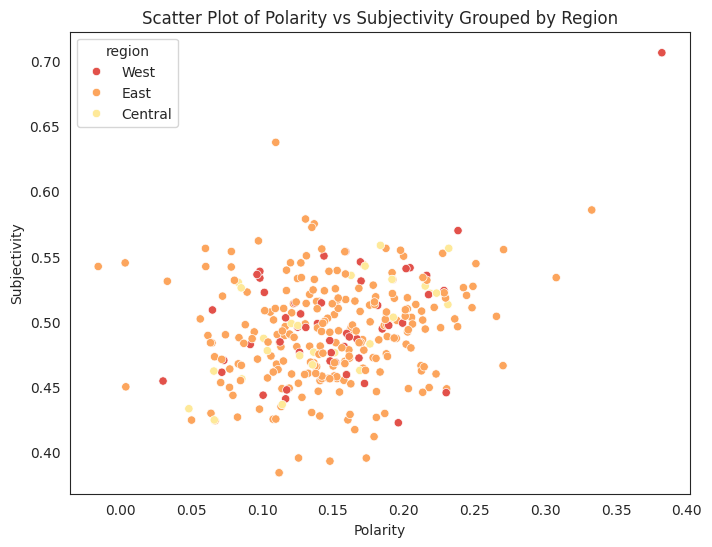

In [ ]:
# Set the color palette
sns.set_palette('Spectral')

# Create scatter plot with points grouped by region
plt.figure(figsize=(8, 6))
sns.scatterplot(x='polarity', y='subjectivity', hue='region', data=speech_speaker_region)

# Add title and labels
plt.title('Scatter Plot of Polarity vs Subjectivity Grouped by Region')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')

# Show plot
plt.show()

##Profession based analysis

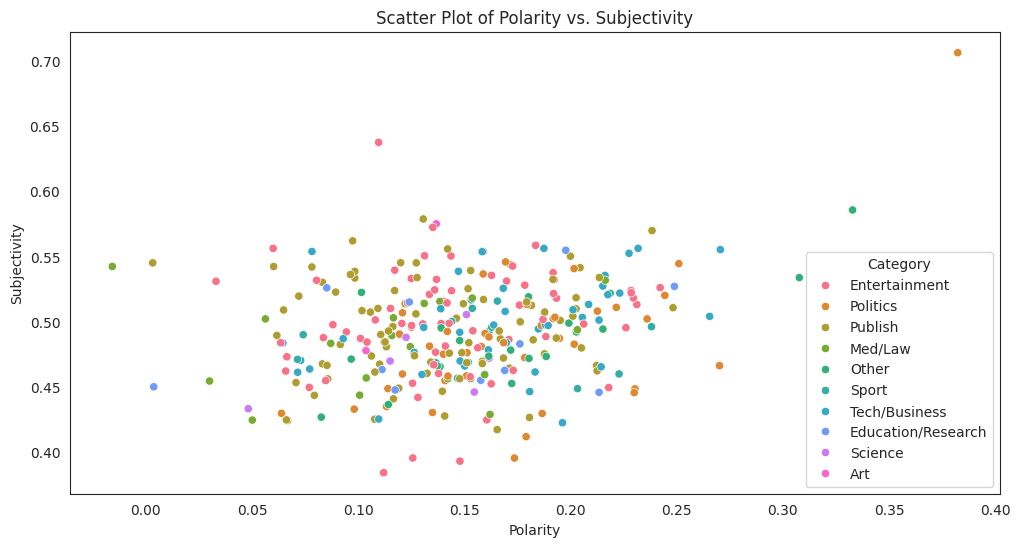

In [ ]:
# Set the color palette
sns.set_palette("Spectral")

# Create a scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=speech_speaker_region, x='polarity', y='subjectivity', hue='category')

# Add labels and title
plt.title('Scatter Plot of Polarity vs. Subjectivity')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')

# Show plot
plt.legend(title='Category')
plt.show()

##Polarity for Different Professions

In [ ]:
# function that return the melt df
def polarity_melt(df,num_split):
    # Split and analyze all transcripts
    all_transcripts = []

    for i in range(df.shape[0]):
        transcript = df.transcript.iloc[i]
        sents = split_text(transcript, n=num_split)
        results = []
        for sent in sents:
            ana = analyzer.polarity_scores(sent)
        #     results.append([ana['neg'],ana['neu'],ana['pos'],ana['compound']])
            results.append(ana['compound'])
        all_transcripts.append(results)

    # Create df
    vader_sent_df = pd.DataFrame(all_transcripts,
                                 columns=[str(i+1) for i in range(num_split)]                            )
    vader_sent_df['Transcript'] = [i for i in range(df.shape[0])]

    # Melt df (for sns lineplot 95% confidence interval)
    vader_sent_melt = pd.melt(vader_sent_df, id_vars='Transcript', value_vars = [str(i+1) for i in range(num_split)],
    #                          val_name = [str(i+1) for i in range(10)]
                             )

    return (vader_sent_melt)

([<matplotlib.axis.YTick at 0x79a42851d5a0>,
 [Text(0, -0.8, '-0.8'), Text(0, 0.0, '0.0'), Text(0, 1.0, '1.0')])

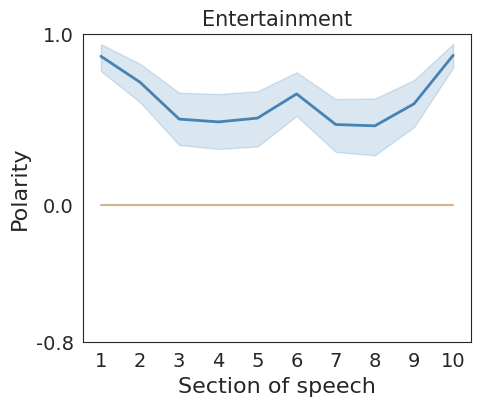

In [ ]:
# Entertainment
sub_df = speech_speaker_region[speech_speaker_region.category == "Entertainment"]
vader_sent_melt = polarity_melt(sub_df,10)

import matplotlib as mpl

fig,ax = plt.subplots(figsize=(5,4))
sns.set_style("white")
sns.lineplot(data=vader_sent_melt, x="variable", y="value",
             color='steelblue',linewidth=2
             )
plt.title('Entertainment',fontsize=15)
plt.ylabel('Polarity',fontsize=16)
plt.xlabel('Section of speech',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot(np.arange(0,10), np.zeros(10),color='tan')
plt.ylim(-.75, 1)
plt.yticks([-0.8, 0 ,1], labels = ['-0.8', '0.0' ,'1.0'], fontsize=14)

([<matplotlib.axis.YTick at 0x79a4279fa680>,
 [Text(0, -0.8, '-0.8'), Text(0, 0.0, '0.0'), Text(0, 1.0, '1.0')])

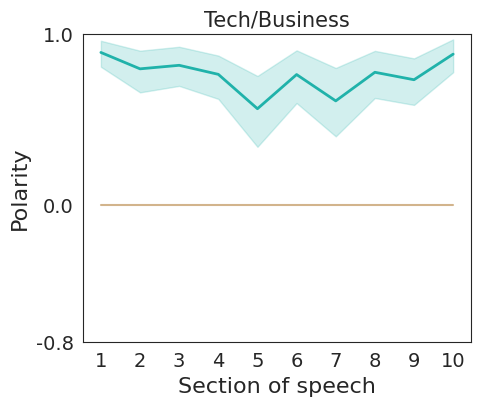

In [ ]:
# Tech/Business
sub_df = speech_speaker_region[speech_speaker_region.category == "Tech/Business"]
vader_sent_melt = polarity_melt(sub_df,10)

import matplotlib as mpl

fig,ax = plt.subplots(figsize=(5,4))
sns.set_style("white")
sns.lineplot(data=vader_sent_melt, x="variable", y="value",
             color='lightseagreen',linewidth=2
             )
plt.title('Tech/Business',fontsize=15)
plt.ylabel('Polarity',fontsize=16)
plt.xlabel('Section of speech',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot(np.arange(0,10), np.zeros(10),color='tan')
plt.ylim(-.75, 1)
plt.yticks([-0.8, 0 ,1], labels = ['-0.8', '0.0' ,'1.0'], fontsize=14)

([<matplotlib.axis.YTick at 0x79a428544040>,
 [Text(0, -0.8, '-0.8'), Text(0, 0.0, '0.0'), Text(0, 1.0, '1.0')])

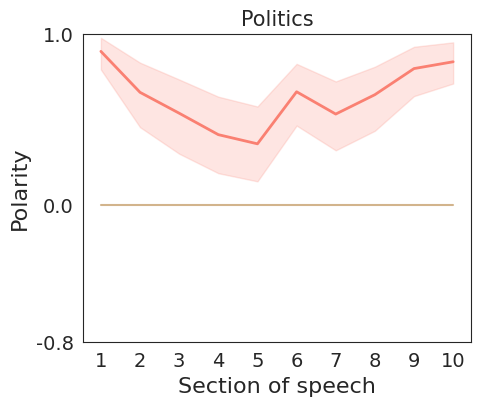

In [ ]:
# Politics
sub_df = speech_speaker_region[speech_speaker_region.category == "Politics"]
vader_sent_melt = polarity_melt(sub_df,10)

import matplotlib as mpl

fig,ax = plt.subplots(figsize=(5,4))
sns.set_style("white")
sns.lineplot(data=vader_sent_melt, x="variable", y="value",
             color='salmon',linewidth=2
             )
plt.title('Politics',fontsize=15)
plt.ylabel('Polarity',fontsize=16)
plt.xlabel('Section of speech',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot(np.arange(0,10), np.zeros(10),color='tan')
plt.ylim(-.75, 1)
plt.yticks([-0.8, 0 ,1], labels = ['-0.8', '0.0' ,'1.0'], fontsize=14)

([<matplotlib.axis.YTick at 0x79a4288624a0>,
 [Text(0, -0.8, '-0.8'), Text(0, 0.0, '0.0'), Text(0, 1.0, '1.0')])

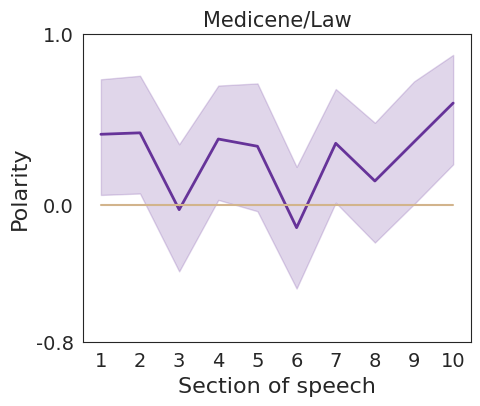

In [ ]:
# Med/Law
sub_df = speech_speaker_region[speech_speaker_region.category == "Med/Law"]
vader_sent_melt = polarity_melt(sub_df,10)

import matplotlib as mpl

fig,ax = plt.subplots(figsize=(5,4))
sns.set_style("white")
sns.lineplot(data=vader_sent_melt, x="variable", y="value",
             color='rebeccapurple',linewidth=2
             )
plt.title('Medicene/Law',fontsize=15)
plt.ylabel('Polarity',fontsize=16)
plt.xlabel('Section of speech',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot(np.arange(0,10), np.zeros(10),color='tan')
plt.ylim(-.75, 1)
plt.yticks([-0.8, 0 ,1], labels = ['-0.8', '0.0' ,'1.0'], fontsize=14)

In [ ]:
def polarity_plot(vader_sent_melt):
    # sns lineplot
#     plt.rcParams['figure.figsize'] = [12, 8]
    sns.lineplot(data=vader_sent_melt, x="variable", y="value")
    plt.title('',fontsize=20)
    plt.ylabel('Average polarity',fontsize=20)
    plt.xlabel('Section of speech',fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=14)

    sns.set_style("white")
    plt.ylim(-.8, 1)
    plt.yticks([-0.8, 0 ,1], labels = ['-0.', '0.0' ,'1.0'], fontsize=14)
    ;

In [ ]:
# Try splitting to more sections
def polarity_all(df,num_split):
    # Split and analyze all transcripts
    all_transcripts = []

    for i in range(df.shape[0]):
        transcript = df.transcript.iloc[i]
        sents = split_text(transcript, n=num_split)
        results = []
        for sent in sents:
            ana = analyzer.polarity_scores(sent)
        #     results.append([ana['neg'],ana['neu'],ana['pos'],ana['compound']])
            results.append(ana['compound'])
        all_transcripts.append(results)

    # Create df
    vader_sent_df = pd.DataFrame(all_transcripts,
                                 columns=[str(i+1) for i in range(num_split)]                            )
    vader_sent_df['Transcript'] = [i for i in range(df.shape[0])]

    # Melt df (for sns lineplot 95% confidence interval)
    vader_sent_melt = pd.melt(vader_sent_df, id_vars='Transcript', value_vars = [str(i+1) for i in range(num_split)],
    #                          val_name = [str(i+1) for i in range(10)]
                             )

#     # sns lineplot
    plt.rcParams['figure.figsize'] = [12, 8]
#     fig,ax = plt.subplots(figsize=(12, 8))
#     sns.lineplot(data=vader_sent_melt, x="variable", y="value")
#     ax.set_title('Average polarity of all speeches over the duration',fontsize=20)
#     ax.set_ylabel('Average polarity',fontsize=20)
#     ax.set_xlabel('Throughout the speech',fontsize=20)
#     plt.xticks(fontsize=18)
#     plt.yticks(fontsize=14);

    return polarity_plot(vader_sent_melt)

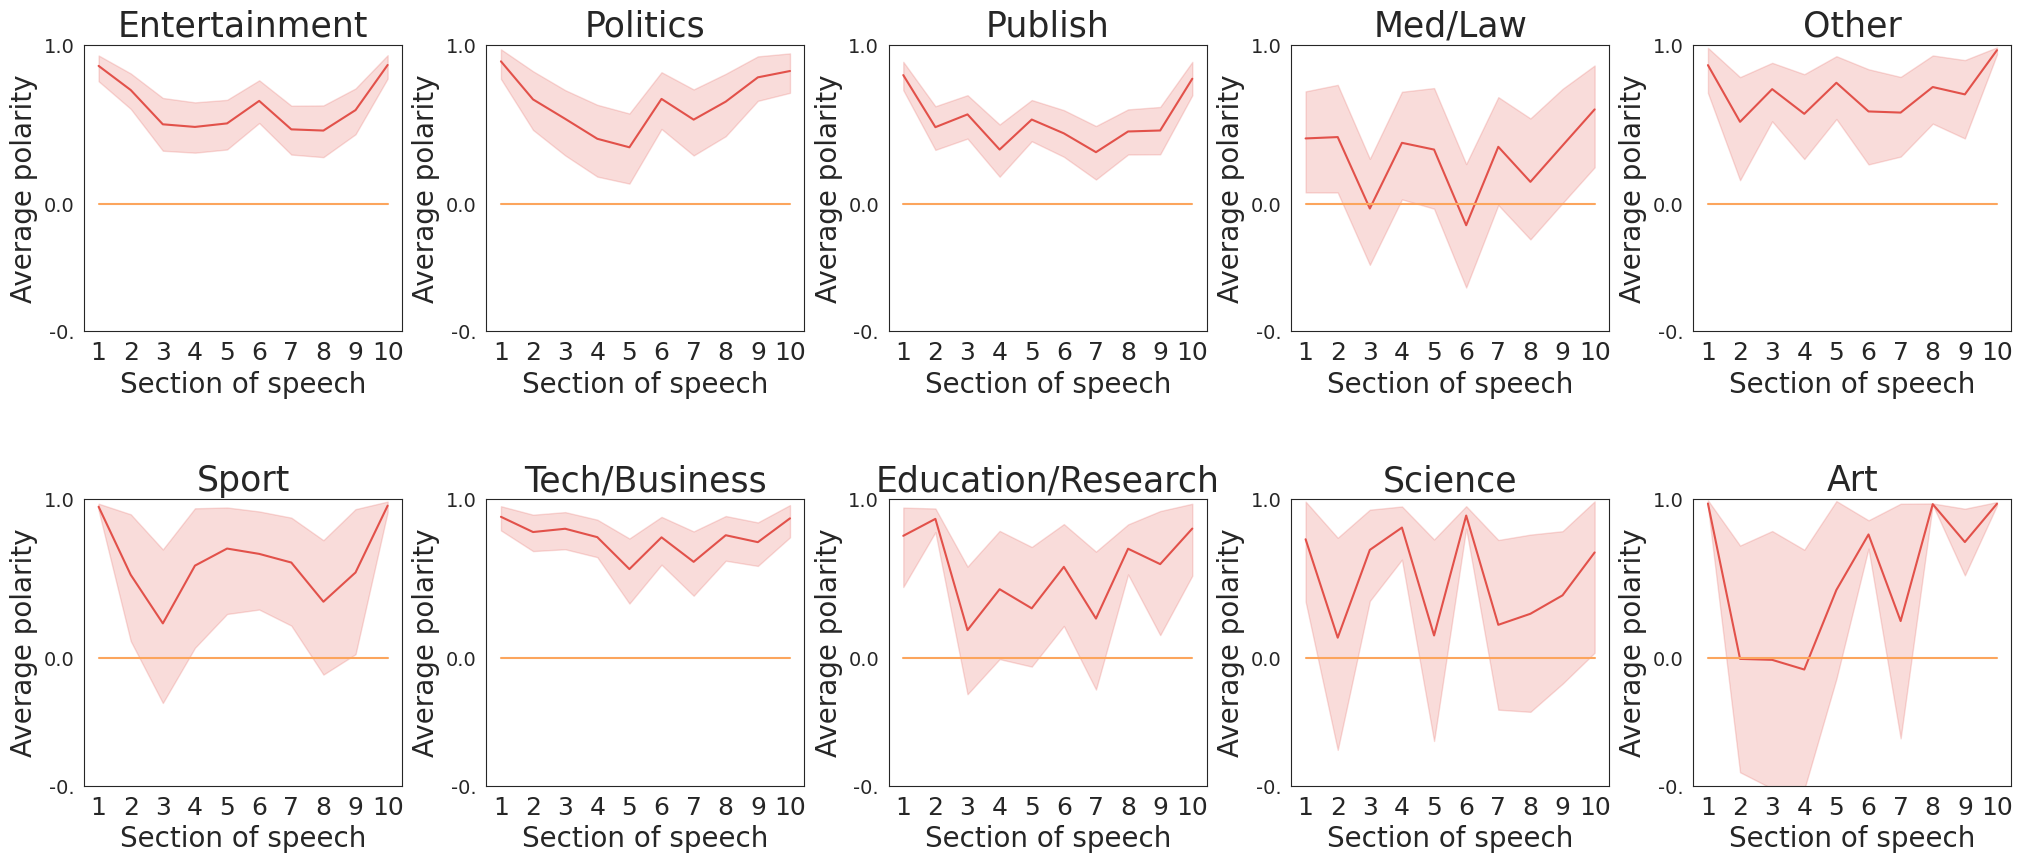

In [ ]:
#All

plt.rcParams['figure.figsize'] = [20, 8]
sns.set_style("white")
sns.set_palette("Spectral")

num_plot = 10
categories = speech_speaker_region.category.unique()

figure, axes = plt.subplots(num_plot//5,5)
figure.tight_layout(h_pad=10.0,w_pad=3.0)

for i in range(num_plot):
    sub_df = speech_speaker_region[speech_speaker_region.category == categories[i]]

    plt.subplot(num_plot//5,5,i+1)
    polarity_all(sub_df,10)
    plt.plot(np.arange(0,10), np.zeros(10))
    plt.title(categories[i], fontdict = {'fontsize' : 25})

plt.show()


#Emotion

In [ ]:
!pip install NRCLex
from nrclex import NRCLex

INFO: pip is looking at multiple versions of nrclex to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for NRCLex: filename=NRCLex-3.0.0-py3-none-any.whl size=43309 sha256=cdc31ad1624f8665c0ab927dfe093e2ffbf9f305d5c269271430190255dc945e
  Stored in directory: /root/.cache/pip/wheels/d2/10/44/6abfb1234298806a145fd6bcaec8cbc712e88dd1cd6cb242fa
Successfully built NRCLex


In [ ]:
filepath = 'NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'
emolex_df = pd.read_csv(filepath, names=["word", "emotion", "association"], skiprows=45, sep='\t', keep_default_na=False)
emolex_df.head(12)

,word,emotion,association
0,abandonment,negative,1
1,abandonment,positive,0
2,abandonment,sadness,1
3,abandonment,surprise,1
4,abandonment,trust,0
5,abate,anger,0
6,abate,anticipation,0
7,abate,disgust,0
8,abate,fear,0
9,abate,joy,0


In [ ]:
# Reshape (pivot)
emolex_words_pivot = emolex_df.pivot(index='word', columns='emotion', values='association').reset_index()
emolex_words_pivot.head()

emotion,word,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
0,abandonment,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0,0.0
1,abate,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,abatement,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,abba,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,abbot,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#Instantiate text object (for best results, 'text' should be unicode).

text_object = NRCLex('text')

In [ ]:
emotion_score_list = []

for i in range(len(speech_df_raw)):
    transcript = speech_df_raw.transcript.iloc[i]
    text_object = NRCLex(transcript)
    emotion_score_list.append(text_object.raw_emotion_scores)

In [ ]:
emotion_score_df = pd.DataFrame(emotion_score_list)
emotion_score_df.head()

,joy,positive,anticipation,surprise,trust,anger,sadness,disgust,fear,negative
0,60,168,68,36,101,49,40.0,25.0,52.0,79
1,87,164,93,40,116,27,34.0,20.0,35.0,59
2,53,197,86,34,111,22,36.0,20.0,43.0,73
3,97,200,87,39,122,45,34.0,27.0,47.0,89
4,92,244,104,44,140,45,42.0,32.0,53.0,98


In [ ]:
# Normalize the score
emotion_score_df['total'] = emotion_score_df.sum(axis=1)
emotion_score_df= emotion_score_df.div(emotion_score_df['total'],axis=0)
emotion_score_df.loc['avg'] = emotion_score_df.mean(axis=0)
emotion_score_df

,joy,positive,anticipation,surprise,trust,anger,sadness,disgust,fear,negative,total
0,0.088496,0.247788,0.100295,0.053097,0.148968,0.072271,0.058997,0.036873,0.076696,0.116519,1.0
1,0.128889,0.242963,0.137778,0.059259,0.171852,0.040000,0.050370,0.029630,0.051852,0.087407,1.0
2,0.078519,0.291852,0.127407,0.050370,0.164444,0.032593,0.053333,0.029630,0.063704,0.108148,1.0
3,0.123253,0.254130,0.110546,0.049555,0.155019,0.057179,0.043202,0.034307,0.059720,0.113088,1.0
4,0.102908,0.272931,0.116331,0.049217,0.156600,0.050336,0.046980,0.035794,0.059284,0.109620,1.0
...,...,...,...,...,...,...,...,...,...,...,...
318,0.103542,0.299728,0.138965,0.043597,0.166213,0.040872,0.051771,0.013624,0.057221,0.084469,1.0
319,0.126506,0.248494,0.121988,0.051205,0.147590,0.048193,0.049699,0.019578,0.070783,0.115964,1.0
320,0.091772,0.227848,0.106013,0.060127,0.123418,0.053797,0.091772,0.052215,0.069620,0.123418,1.0
321,0.131291,0.245077,0.126915,0.048140,0.170678,0.032823,0.067834,0.035011,0.052516,0.089716,1.0


<ipython-input-77-79cb974cca1b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_score_df.iloc[-1,:-1],y=emotion_score_df.columns[:-1],\


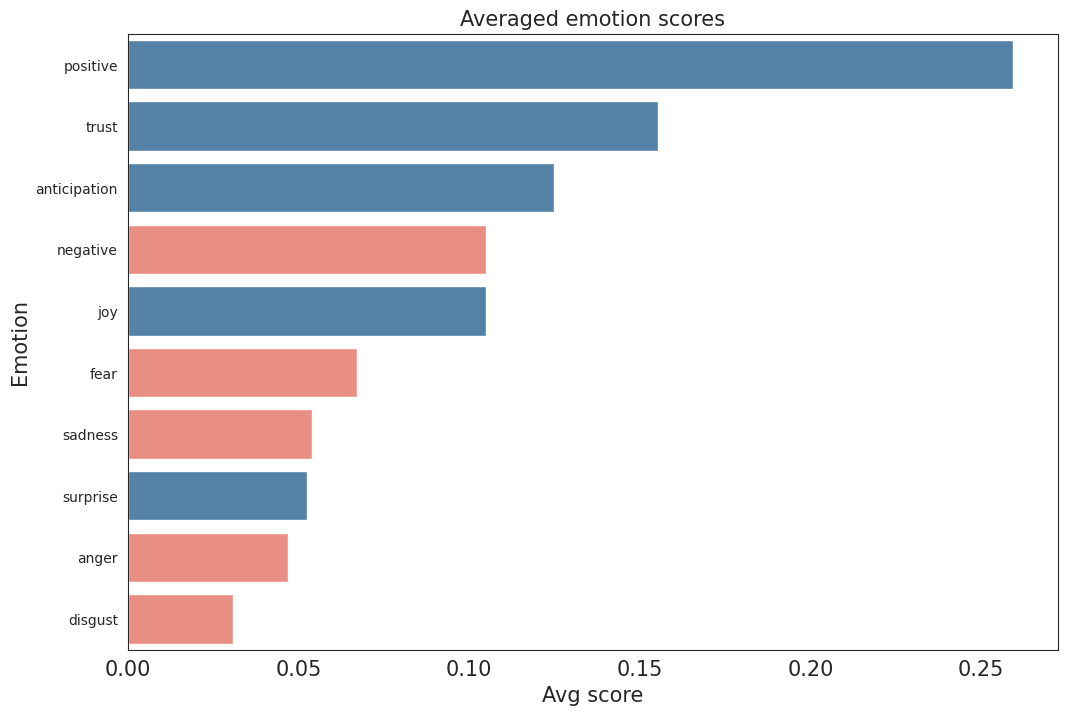

In [ ]:
# Plot with sns

fig, ax = plt.subplots()
colors = ['steelblue' if (y in ['positive','trust','joy','anticipation','surprise']) else 'salmon'
          for y in emotion_score_df.iloc[:,:-1].mean(axis=0).sort_values(ascending=False).index]
sns.barplot(x=emotion_score_df.iloc[-1,:-1],y=emotion_score_df.columns[:-1],\
           order=emotion_score_df.iloc[:,:-1].mean(axis=0).sort_values(ascending=False).index,\
           palette = colors)

ax.set_title('Averaged emotion scores',fontsize=15)
ax.set_ylabel('Emotion',fontsize=15)
ax.set_xlabel('Avg score',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=10);